### Contexto e Objetivo

Está sendo desenvolvido um modelo de classificação de dados em uma base de serviço para avaliar se um cliente irá continuar no serviço ou irá cancelá-lo. Essa analise poderá ser util para identificar as chances do cliente querer desistir do serviço que possui, e avaliar os fatores que podem afetar nessa decisão


Importação de Dependências

In [1]:
from functions import gini_coeficient
import pandas as pd
import numpy as np 

import seaborn as sns
import matplotlib.pyplot as plt 

import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.precision', 2)

In [2]:
df_credit = pd.read_csv(r"..\\documents\\Credit_Card_Churn.csv")

# Análise Inicial da base de Crédito

In [3]:
# Não apresenta nenhum valor nulo

df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10000 non-null  int64  
 1   Attrition_Flag            10000 non-null  object 
 2   Customer_Age              10000 non-null  int64  
 3   Gender                    10000 non-null  object 
 4   Dependent_count           10000 non-null  int64  
 5   Education_Level           10000 non-null  object 
 6   Marital_Status            10000 non-null  object 
 7   Income_Category           10000 non-null  object 
 8   Card_Category             10000 non-null  object 
 9   Months_on_book            10000 non-null  int64  
 10  Total_Relationship_Count  10000 non-null  int64  
 11  Months_Inactive_12_mon    10000 non-null  int64  
 12  Contacts_Count_12_mon     10000 non-null  int64  
 13  Credit_Limit              10000 non-null  float64
 14  Total_R

Análise de valores únicos

In [4]:
for x in df_credit.columns:
    print(f'Coluna: {x}')
    print(np.sort(df_credit[x].unique()), "\n")
    

Coluna: CLIENTNUM
[100000000 100000001 100000002 ... 100009997 100009998 100009999] 

Coluna: Attrition_Flag
['Attrited Customer' 'Existing Customer'] 

Coluna: Customer_Age
[26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49
 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72] 

Coluna: Gender
['F' 'M'] 

Coluna: Dependent_count
[0 1 2 3 4 5] 

Coluna: Education_Level
['College' 'Doctorate' 'Graduate' 'High School' 'Post-Graduate'
 'Uneducated'] 

Coluna: Marital_Status
['Divorced' 'Married' 'Single'] 

Coluna: Income_Category
['$120K +' '$40K - $60K' '$60K - $80K' '$80K - $120K' 'Less than $40K'
 'Unknown'] 

Coluna: Card_Category
['Blue' 'Gold' 'Platinum' 'Silver'] 

Coluna: Months_on_book
[12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35
 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59
 60] 

Coluna: Total_Relationship_Count
[1 2 3 4 5 6] 

Coluna: Months_Inactive_12_mon
[0 1 2 3 4 5 6] 

Coluna: 

Avaliar se o dataset apresenta valores numéricos abaixo de 0

In [5]:
colunas_numericas = [c for c in df_credit.columns if df_credit[c].dtype != 'object']

print("Colunas com valores abaixo de 0:")

for c in colunas_numericas:
    if (df_credit[c] < 0).any():
        print(c)


Colunas com valores abaixo de 0:
Avg_Open_To_Buy


In [6]:
# Análise percentual de clientes que cancelaram o cartão de crédito

df_credit['Attrition_Flag'].value_counts(normalize=True)

Attrition_Flag
Existing Customer    0.85
Attrited Customer    0.15
Name: proportion, dtype: float64

In [7]:
# Análise percentual de clientes que cancelaram o cartão de crédito por tipo de cartão

df_credit.groupby("Card_Category")['Attrition_Flag'].value_counts(normalize=True)

Card_Category  Attrition_Flag   
Blue           Existing Customer    0.84
               Attrited Customer    0.16
Gold           Existing Customer    0.87
               Attrited Customer    0.13
Platinum       Existing Customer    0.90
               Attrited Customer    0.10
Silver         Existing Customer    0.86
               Attrited Customer    0.14
Name: proportion, dtype: float64

# Tratamento dos Dados

Nessa estapa está sendo adaptado as colunas em string para padrões numérico para avaliar o quanto elas se correlacionam entre si e então descartando as colunas que poderiam confundir o modelo

In [8]:
df_base_credit = df_credit.copy()


income_category_map = {"Less than $40K": 1, "$40K - $60K": 2,
                       "$60K - $80K": 3, "$80K - $120K": 4, "$120K +": 5} # "Unknown": 0,

df_base_credit['Income_Category'] = df_base_credit['Income_Category'].map(income_category_map)

# foi calculado a mediana pois com o valor Unknown daria a entender que seria o menor renda possivel
mediana_income_category = df_base_credit['Income_Category'].median()

df_base_credit['Income_Category'] = df_base_credit['Income_Category'].fillna(mediana_income_category).astype("int")


atrition_flag_map = {
    'Attrited Customer': 1,
    'Existing Customer': 0
}
df_base_credit['Attrition_Flag'] = df_base_credit['Attrition_Flag'].map(atrition_flag_map).astype("int")


df_base_credit['Is_Male'] = df_base_credit['Gender'].map(lambda x: x == 'M').astype("int")
df_base_credit['Is_Female'] = df_base_credit['Gender'].map(lambda x: x == 'F').astype("int")


df_base_credit['Is_Uneducated'] = df_base_credit['Education_Level'].map(lambda x: x == 'Uneducated').astype("int")

df_base_credit['Education_HighSchool'] = df_base_credit['Education_Level'].map(lambda x: x == 'High School'
                                                                        ).astype("int")

df_base_credit['Education_College'] = df_base_credit['Education_Level'].map(lambda x: x == 'College'
                                                                        ).astype("int")

df_base_credit['Education_Graduate'] = df_base_credit['Education_Level'].map(lambda x: x == 'Graduate'
                                                                        ).astype("int")

df_base_credit['Education_Post_Graduate'] = df_base_credit['Education_Level'].map(lambda x: x == 'Post-Graduate'
                                                                        ).astype("int")

df_base_credit['Education_Doctorate'] = df_base_credit['Education_Level'].map(lambda x: x == 'Doctorate'
                                                                        ).astype("int")


df_base_credit['Status_Divorced'] = df_base_credit['Marital_Status'].map(lambda x: x == 'Divorced').astype("int")
df_base_credit['Status_Single'] = df_base_credit['Marital_Status'].map(lambda x: x == 'Single').astype("int")
df_base_credit['Status_Married'] = df_base_credit['Marital_Status'].map(lambda x: x == 'Married').astype("int")


df_base_credit['Is_Blue_Card'] = df_base_credit['Card_Category'].map(lambda x: x == 'Blue').astype("int")
df_base_credit['Is_Silver_Card'] = df_base_credit['Card_Category'].map(lambda x: x == 'Silver').astype("int")
df_base_credit['Is_Gold_Card'] = df_base_credit['Card_Category'].map(lambda x: x == 'Gold').astype("int")
df_base_credit['Is_Platinum_Card'] = df_base_credit['Card_Category'].map(lambda x: x == 'Platinum').astype("int")


Correlação das variáveis


foram criados graficos Heatmap para:

* Identificar a Multicolinearidade entre as variáveis, ou seja, se duas dizem basicamente a mesma coisa, 
foi criado um grafico heatmap para

* Avaliar as colunas One-Hot-Encoding, (dividir um valor em string como 0 ou 1)

* Identificar as correlações altas


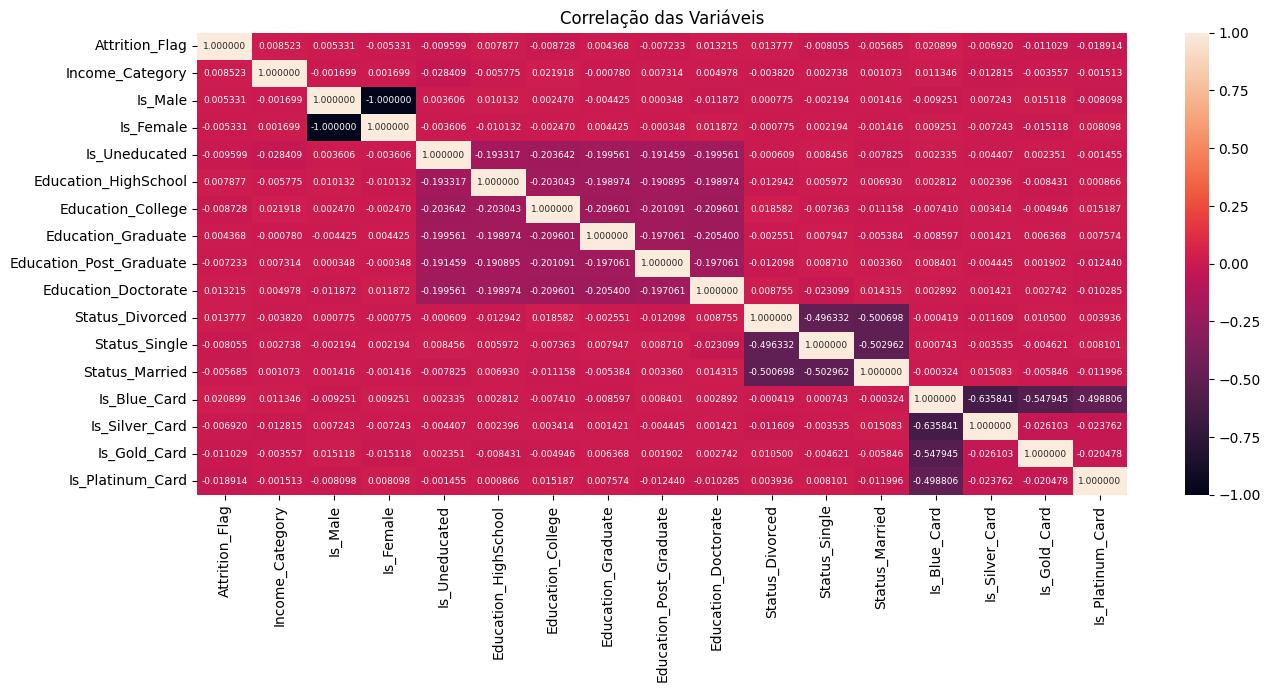

In [9]:
df_encoding_correlations = df_base_credit[['Attrition_Flag', 'Income_Category',
                              'Is_Male', 'Is_Female', 'Is_Uneducated', 'Education_HighSchool',
                              'Education_College', 'Education_Graduate', 'Education_Post_Graduate', 'Education_Doctorate', 'Status_Divorced', 'Status_Single', 'Status_Married',
                              'Is_Blue_Card', 'Is_Silver_Card', 'Is_Gold_Card', 'Is_Platinum_Card'
                              ]].corr()

plt.figure(figsize=(15, 6))

sns.heatmap(data=df_encoding_correlations, 
            annot=True, fmt=".6f", annot_kws={"size": 6.5})
plt.title("Correlação das Variáveis")
plt.show()

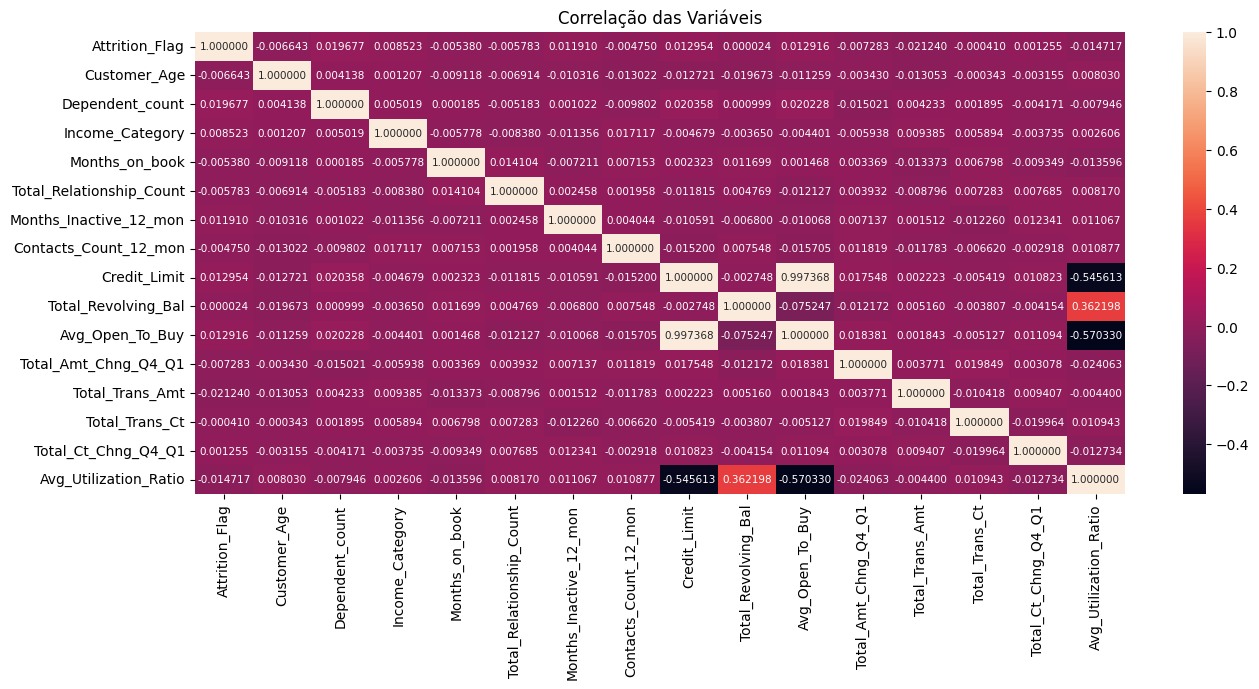

In [10]:
df_correlations = df_base_credit.drop(columns=['Gender', 'CLIENTNUM', 'Marital_Status', 
                                          'Card_Category', 'Education_Level',

                                          'Is_Male', 'Is_Female', 

                                          'Is_Uneducated', 'Education_HighSchool',
                                          'Education_College', 'Education_Graduate', 
                                          'Education_Post_Graduate', 'Education_Doctorate', 
                                          
                                          'Status_Divorced', 'Status_Single', 'Status_Married',
                                          'Is_Blue_Card', 'Is_Silver_Card', 'Is_Gold_Card', 'Is_Platinum_Card'
                                   ]).corr()

plt.figure(figsize=(15, 6))

sns.heatmap(data=df_correlations, 
            annot=True, fmt=".6f", annot_kws={"size": 7.5})
plt.title("Correlação das Variáveis")
plt.show()

Conclusões

* A coluna CLIENTNUM será removida pois apresenta 
  valores constantes, atrapalhando na classificação dos dados

* a coluna Avg_Open_To_Buy (Credit_Limit - Total_Revolving_Bal) apresenta uma 
  correlação alta com o Credit_Limit, chegando a ser a mesma variável,
  porém o Credit_Limit tem uma correlação mais forte com a coluna target;
  Portanto a coluna Avg_Open_To_Buy deve ser removida


Avaliação das colunas suspeitas

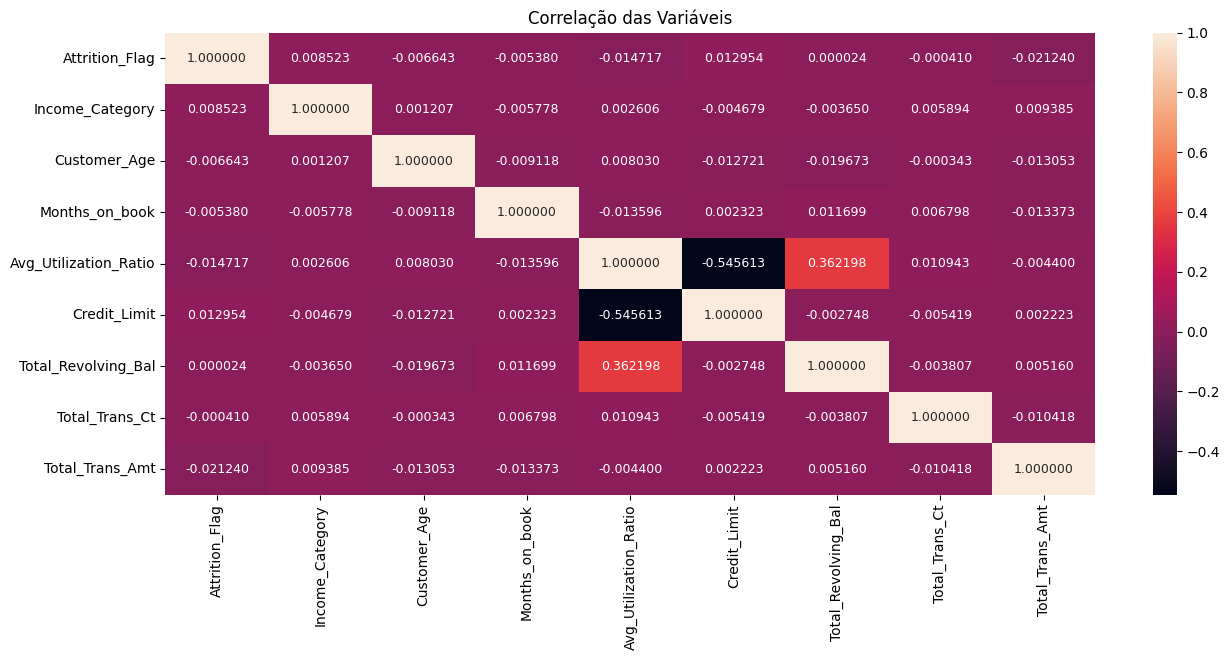

In [11]:
df_hetamap_test = df_base_credit[['Attrition_Flag',  'Income_Category', 
                                  'Customer_Age', 'Months_on_book',
                                  'Avg_Utilization_Ratio','Credit_Limit', 
                                  'Total_Revolving_Bal', 'Total_Trans_Ct', 'Total_Trans_Amt']].corr()

plt.figure(figsize=(15, 6))

sns.heatmap(data=df_hetamap_test, 
            annot=True, fmt=".6f", annot_kws={"size": 9})
plt.title("Correlação das Variáveis")
plt.show()

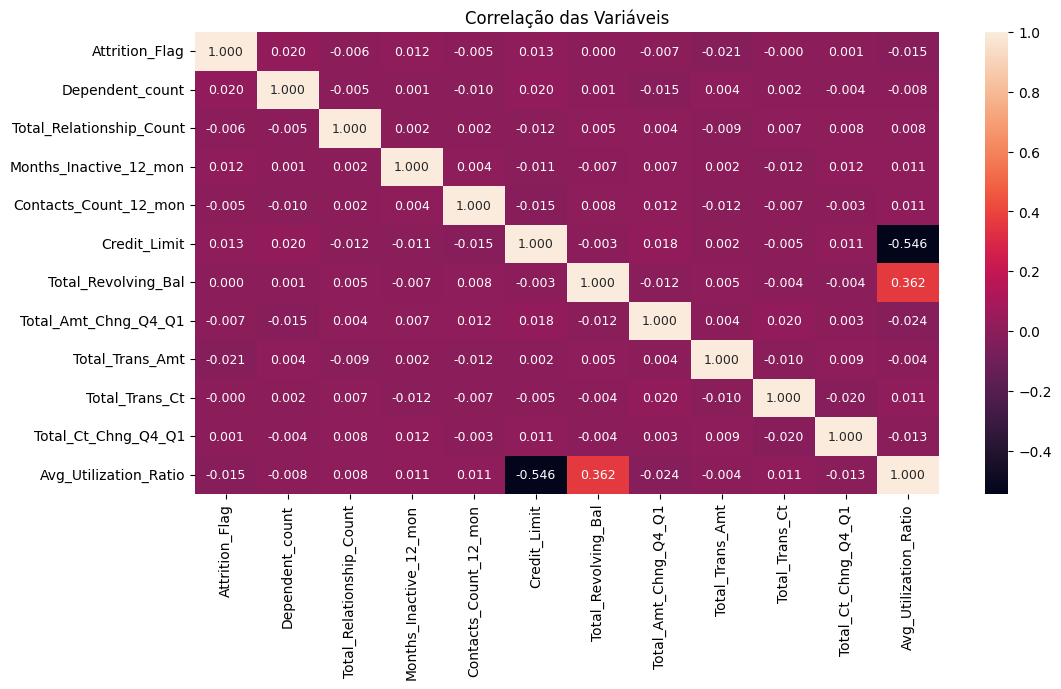

In [12]:
df_credit_clean = df_base_credit.drop(columns=[
                                          'Gender', 'CLIENTNUM', 'Marital_Status', 
                                          'Card_Category', 'Education_Level',

                                          'Avg_Open_To_Buy', 'Months_on_book', 'Customer_Age',

                                          'Is_Male', 'Is_Female',  'Income_Category',
                                          
                                          'Is_Uneducated', 'Education_HighSchool',
                                          'Education_College', 'Education_Graduate', 
                                          'Education_Post_Graduate', 'Education_Doctorate', 
                                          
                                          'Status_Divorced', 'Status_Single', 'Status_Married',
                                          
                                          'Is_Blue_Card', 'Is_Silver_Card', 'Is_Gold_Card', 'Is_Platinum_Card'
                                            ])


plt.figure(figsize=(12, 6))

sns.heatmap(data=df_credit_clean.corr(), 
            annot=True, fmt=".3f", annot_kws={"size": 9})
plt.title("Correlação das Variáveis")
plt.show()

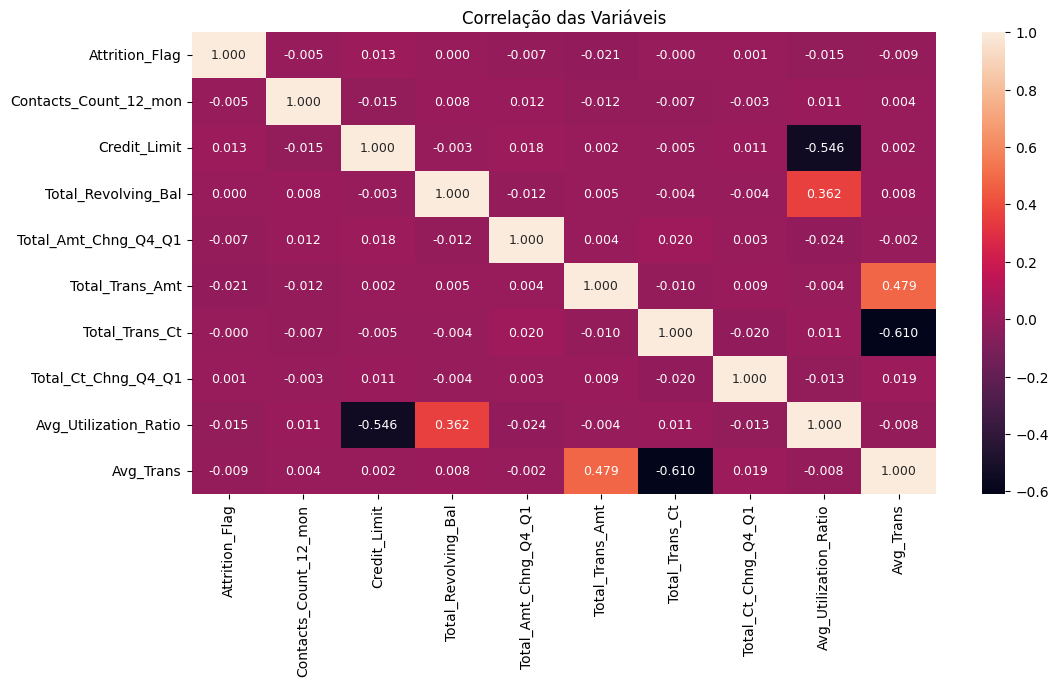

In [13]:

#df_credit_clean['Trans_per_Month'] = round(df_credit_clean['Total_Trans_Ct']/df_credit_clean['Months_on_book'],2)

df_credit_clean['Avg_Trans'] = round(df_credit_clean['Total_Trans_Amt']/df_credit_clean['Total_Trans_Ct'],2)
#df_credit_clean['Utilization_Rate'] = round(df_credit_clean['Total_Revolving_Bal']/df_credit_clean['Credit_Limit'],2)


df_credit_clean = df_credit_clean.drop(columns=['Total_Relationship_Count', 
                                                'Months_Inactive_12_mon', 'Dependent_count'])

plt.figure(figsize=(12, 6))

sns.heatmap(data=df_credit_clean.corr(), 
            annot=True, fmt=".3f", annot_kws={"size": 9})
plt.title("Correlação das Variáveis")
plt.show()

Definição das variáveis de treino e teste

In [14]:
X = df_credit_clean.drop(columns=['Attrition_Flag'], axis=1)
y = df_credit_clean['Attrition_Flag']

# Será dividido os dados dos eixos x e y em 80% de treino e 20% de teste
# stratify -> variável alvo
# random_state -> trava o sorteio para ser sempre igual

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42, stratify=y)

# Modelo de Regressão Logística

In [15]:
# Deve ser aplicado o StandardScaler para que o Modelo de Regressão Logística
# consiga colocar todas as variáveis na mesma escala

scaler = StandardScaler()

X_train_scalled = scaler.fit_transform(X_train)
X_test_scalled = scaler.transform(X_test)

In [16]:
# criação do modelo
logistic_regression = LogisticRegression(class_weight='balanced', max_iter=2000)

# treinamento do modelo
logistic_regression.fit(X_train_scalled, Y_train)


# Coeficiente de Gini
# caso o coeficiente esteja menor que 0 quer dizer que o modelo está invertendo previsões
# se for 0 o modelo é aleatiro, se for 1 o modelo é perfeito

gini_lr = gini_coeficient(model=logistic_regression, X_test=X_test_scalled, Y_Test=Y_test)

print(f'Coeficiente de Gini (Logistic Regression): {gini_lr}')


Area Under Reciver: 0.5173448005894814
Coeficiente de Gini (Logistic Regression): 0.0346896011789628


In [17]:
# Previsão do modelo
pred_lr = logistic_regression.predict(X_test_scalled)

print(f"Matriz de Confusão (Logistic Regression):\n{confusion_matrix(Y_test, pred_lr)}\n")

print(f"Relatório Logistic Regression:\n {
                classification_report(Y_test, pred_lr, 
                                      target_names=["Churn", "Permaneceu"], zero_division=0)
            }")


Matriz de Confusão (Logistic Regression):
[[847 845]
 [144 164]]

Relatório Logistic Regression:
               precision    recall  f1-score   support

       Churn       0.85      0.50      0.63      1692
  Permaneceu       0.16      0.53      0.25       308

    accuracy                           0.51      2000
   macro avg       0.51      0.52      0.44      2000
weighted avg       0.75      0.51      0.57      2000



Avaliação do Limite apropriado

para avaliar o limite de dados adequado para comparar na matriz de confusão
será testado um grupo de limites de 0 a 1 identificando qual intervalo seria mais apropriado

In [18]:
# Comparativo com os Limites do Logistic Regression

prob_lr = logistic_regression.predict_proba(X_test_scalled)[:, 1]

for lmt in np.arange(0.1, 1, 0.1):
    print(f"Matriz de Confusão - Limite {lmt:.2f}")
    print(confusion_matrix(Y_test, (prob_lr > lmt).astype("int") ), "\n")


Matriz de Confusão - Limite 0.10
[[   0 1692]
 [   0  308]] 

Matriz de Confusão - Limite 0.20
[[   0 1692]
 [   0  308]] 

Matriz de Confusão - Limite 0.30
[[   0 1692]
 [   0  308]] 

Matriz de Confusão - Limite 0.40
[[   0 1692]
 [   0  308]] 

Matriz de Confusão - Limite 0.50
[[847 845]
 [144 164]] 

Matriz de Confusão - Limite 0.60
[[1692    0]
 [ 308    0]] 

Matriz de Confusão - Limite 0.70
[[1692    0]
 [ 308    0]] 

Matriz de Confusão - Limite 0.80
[[1692    0]
 [ 308    0]] 

Matriz de Confusão - Limite 0.90
[[1692    0]
 [ 308    0]] 



Nos comparativos, foi apresentado que o limite seria de 0.5, porém esse é o mesmo limite ao usar o o predict para identificar os valores esperados

In [19]:
pred_proba_lr = (prob_lr > 0.45).astype("int")

print(f"Matriz de Confusão (Logistic Regression):\n{confusion_matrix(Y_test, pred_proba_lr)}\n")

print(f"Relatório Logistic Regression:\n {
                classification_report(Y_test, pred_proba_lr, 
                                      target_names=["Churn", "Permaneceu"], zero_division=0)
            }")


Matriz de Confusão (Logistic Regression):
[[  11 1681]
 [   2  306]]

Relatório Logistic Regression:
               precision    recall  f1-score   support

       Churn       0.85      0.01      0.01      1692
  Permaneceu       0.15      0.99      0.27       308

    accuracy                           0.16      2000
   macro avg       0.50      0.50      0.14      2000
weighted avg       0.74      0.16      0.05      2000



In [20]:
# Análise de quais são as colunas que mais estão sendo utilizadas no modelo

df_importancia = pd.DataFrame({
    'Importância': logistic_regression.coef_[0]  
    }, index=X_train.columns
).sort_values(by='Importância', ascending=False).reset_index(names='Coluna')

df_importancia

,Coluna,Importância
0,Credit_Limit,3.44e-02
1,Total_Trans_Ct,1.92e-02
2,Avg_Trans,1.04e-02
3,Total_Revolving_Bal,-8.30e-04
4,Total_Ct_Chng_Q4_Q1,-1.05e-03
5,Contacts_Count_12_mon,-6.54e-03
6,Avg_Utilization_Ratio,-1.55e-02
7,Total_Amt_Chng_Q4_Q1,-3.85e-02
8,Total_Trans_Amt,-5.08e-02


# Random Florest

In [21]:
# Modelo Random Florest

# criação do modelo
random_florest = RandomForestClassifier(
    n_estimators=100, # quantidade de estimativas
    max_depth=8, # impede que os dados sejam decorados
    class_weight='balanced', # balanceamento de pesos
    random_state=42
) 

# treinar o modelo
random_florest.fit(X_train, Y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [22]:
# Coeficiente de Gini
# caso o coeficiente esteja menor que 0 quer dizer que o modelo está invertendo previsões
# se for 0 o modelo é aleatiro, se for 1 o modelo é perfeito

gini_rf = gini_coeficient(model=random_florest, X_test=X_test, Y_Test=Y_test)

print(f'Coeficiente de Gini (Random Florest): {gini_rf}')

Area Under Reciver: 0.4825937950937951
Coeficiente de Gini (Random Florest): -0.03481240981240985


Avaliação do Limite apropriado

para avaliar o limite de dados adequado para comparar na matriz de confusão
será testado um grupo de limites de 0 a 1 identificando qual intervalo seria mais apropriado


In [23]:
prob_rf = logistic_regression.predict_proba(X_test_scalled)[:, 1]

for lmt in np.arange(0, 1, 0.1):
    print(f'Matriz de Confusão Limite {lmt:.2f}')
    print(f"{confusion_matrix(Y_test, (prob_rf > lmt).astype("int")  )}\n")


Matriz de Confusão Limite 0.00
[[   0 1692]
 [   0  308]]

Matriz de Confusão Limite 0.10
[[   0 1692]
 [   0  308]]

Matriz de Confusão Limite 0.20
[[   0 1692]
 [   0  308]]

Matriz de Confusão Limite 0.30
[[   0 1692]
 [   0  308]]

Matriz de Confusão Limite 0.40
[[   0 1692]
 [   0  308]]

Matriz de Confusão Limite 0.50
[[847 845]
 [144 164]]

Matriz de Confusão Limite 0.60
[[1692    0]
 [ 308    0]]

Matriz de Confusão Limite 0.70
[[1692    0]
 [ 308    0]]

Matriz de Confusão Limite 0.80
[[1692    0]
 [ 308    0]]

Matriz de Confusão Limite 0.90
[[1692    0]
 [ 308    0]]



In [24]:
# Previsão do modelo

#pred_rf = random_florest.predict(X_test)
pred_rf = (prob_rf > 0.45).astype("int") 

print(f"Matriz de Confusão (Random Florest):\n{confusion_matrix(Y_test, pred_rf  )}\n")

print(f"Relatório Random Florest:\n {
                classification_report(
                    Y_test, pred_rf, target_names=['Churn', 'Permaneceu'],
                    zero_division=0 # define o valor a retornar caso tenha alguma divisão por 0
                )
            }")


Matriz de Confusão (Random Florest):
[[  11 1681]
 [   2  306]]

Relatório Random Florest:
               precision    recall  f1-score   support

       Churn       0.85      0.01      0.01      1692
  Permaneceu       0.15      0.99      0.27       308

    accuracy                           0.16      2000
   macro avg       0.50      0.50      0.14      2000
weighted avg       0.74      0.16      0.05      2000



In [25]:
df_importancia = pd.DataFrame({
    'Importância': random_florest.feature_importances_  
    }, index=X_train.columns
).sort_values(by='Importância', ascending=False).reset_index(names='Coluna')

df_importancia

,Coluna,Importância
0,Credit_Limit,0.14
1,Total_Revolving_Bal,0.13
2,Avg_Trans,0.13
3,Total_Trans_Amt,0.13
4,Total_Ct_Chng_Q4_Q1,0.12
5,Total_Amt_Chng_Q4_Q1,0.12
6,Total_Trans_Ct,0.11
7,Avg_Utilization_Ratio,0.08
8,Contacts_Count_12_mon,0.05


# XGBoost Classifier

In [26]:
# criação do modelo
xgboost_classifier = xgb.XGBClassifier(scale_pos_weight=5.5,  # incluir mais 5.5 de peso ao churn
                                       random_state=42) 

# treinamento do modelo
xgboost_classifier.fit(X_train, Y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [27]:
# Coeficiente de Gini
# caso o coeficiente esteja menor que 0 quer dizer que o modelo está invertendo previsões
# se for 0 o modelo é aleatiro, se for 1 o modelo é perfeito

gini_xgboost = gini_coeficient(model=xgboost_classifier, X_test=X_test, Y_Test=Y_test)

print(f'Coeficiente de Gini (XGBOOST Classifier): {gini_xgboost}')

Area Under Reciver: 0.4645505204015843
Coeficiente de Gini (XGBOOST Classifier): -0.07089895919683142


Avaliação do Limite para Matriz de Confusão

In [28]:
prob_xgboot = xgboost_classifier.predict_proba(X_test)[:, 1]

for lmt in np.arange(0, 1, 0.1):
    print(f'Matriz de Confusão {lmt}')
    print(confusion_matrix(Y_test, (prob_xgboot > lmt).astype("int") ), "\n")

Matriz de Confusão 0.0
[[   0 1692]
 [   0  308]] 

Matriz de Confusão 0.1
[[ 324 1368]
 [  70  238]] 

Matriz de Confusão 0.2
[[716 976]
 [139 169]] 

Matriz de Confusão 0.30000000000000004
[[1027  665]
 [ 209   99]] 

Matriz de Confusão 0.4
[[1260  432]
 [ 247   61]] 

Matriz de Confusão 0.5
[[1443  249]
 [ 276   32]] 

Matriz de Confusão 0.6000000000000001
[[1574  118]
 [ 290   18]] 

Matriz de Confusão 0.7000000000000001
[[1649   43]
 [ 302    6]] 

Matriz de Confusão 0.8
[[1679   13]
 [ 305    3]] 

Matriz de Confusão 0.9
[[1691    1]
 [ 307    1]] 



In [29]:
# Previsão do modelo
#pred_xgboot = xgboot_classifier.predict(X_test)
pred_xgboot = (prob_xgboot > 0.15).astype("int") 

print(f"Matriz de Confusão:\n{confusion_matrix(Y_test, pred_xgboot)}\n")

print(f"Relatório XGBOOST Classifier:\n {
                classification_report(
                    Y_test, pred_xgboot, target_names=['Churn', 'Permaneceu'],
                    zero_division=0
                )
            }")


Matriz de Confusão:
[[ 536 1156]
 [ 105  203]]

Relatório XGBOOST Classifier:
               precision    recall  f1-score   support

       Churn       0.84      0.32      0.46      1692
  Permaneceu       0.15      0.66      0.24       308

    accuracy                           0.37      2000
   macro avg       0.49      0.49      0.35      2000
weighted avg       0.73      0.37      0.43      2000



In [30]:
df_importancia = pd.DataFrame({
    'Importância': xgboost_classifier.feature_importances_  
    }, index=X_train.columns
).sort_values(by='Importância', ascending=False).reset_index(names='Coluna')

df_importancia

,Coluna,Importância
0,Total_Trans_Ct,0.12
1,Avg_Trans,0.12
2,Credit_Limit,0.11
3,Total_Revolving_Bal,0.11
4,Total_Amt_Chng_Q4_Q1,0.11
5,Avg_Utilization_Ratio,0.11
6,Total_Trans_Amt,0.11
7,Total_Ct_Chng_Q4_Q1,0.11
8,Contacts_Count_12_mon,0.10
